# Data, censoring, and the mediator problem

Three properties of FreshRetailNet-50K shape everything downstream: there is
no price column, sales are censored by stockouts, and stock levels are not
published. This notebook documents what the data contains, how each gap was
closed, and one finding that changes the economics of the whole problem.

All logic lives in `src/`; this notebook imports and displays.

In [20]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import ACTION_GRID, FIGURES_DIR, RESULTS_DIR, ensure_dirs
from src.data import (
    build_feature_matrix,
    build_recovered_dataset,
    daily_censoring_rate,
    explode_hourly,
    get_feature_names,
    hourly_censoring_rate,
    load_or_create_subset,
    temporal_split,
)

import os

# The notebook reports one specific run. Fixing it here rather than reading
# the environment means the file opens with the same results wherever it is
# run, which is what a reviewer needs.
os.environ.setdefault("AIDDM_RUN", "city0_lgbm")
os.environ.setdefault("AIDDM_CITY", "0")
os.environ.setdefault("AIDDM_SIMULATOR", "lgbm")

sys.path.insert(0, str(Path.cwd().parent))

ensure_dirs()
pd.set_option("display.width", 120)

## 1. The working subset

City 0 holds 2.32M of the 4.5M training rows. Category is a model feature
rather than a filter: restricting to one category leaves 34 store-product
pairs, too few to identify a price response across eight action levels.
Pairs are ranked by promotional days, because price response is identified
by variation in the action and a pair held at full price contributes none.

In [21]:
subset = load_or_create_subset()
summary = pd.read_csv(RESULTS_DIR / "dataset_summary.csv", index_col=0, header=None)
summary.columns = ["value"]
summary

,value
0,
city_id,0.000000
rows,38800.000000
pairs,400.000000
stores,6.000000
products,170.000000
days,97.000000
promo_share,0.473428
campaign_price_correlation,-0.783066
hourly_censoring_rate,0.184853


## 2. The price multiplier is not a managerial lever

`discount` takes 2,600 distinct values with roughly half the mass at exactly
1.0. It is a realised price ratio computed from transactions, not a dial set
by a manager — which matters for how the action space is interpreted.

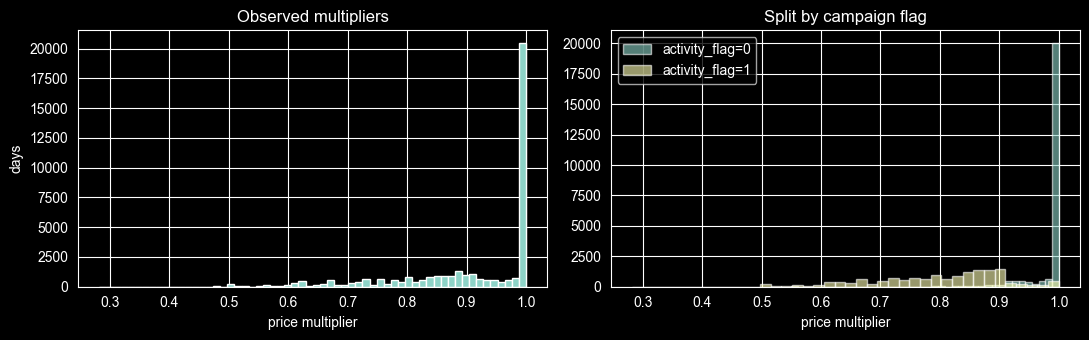

correlation between the campaign flag and the multiplier: -0.783


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
subset["discount"].hist(bins=60, ax=axes[0])
axes[0].set(xlabel="price multiplier", ylabel="days", title="Observed multipliers")

promo = subset.groupby("activity_flag")["discount"]
for flag, values in promo:
    axes[1].hist(values, bins=40, alpha=0.6, label=f"activity_flag={flag}")
axes[1].set(xlabel="price multiplier", title="Split by campaign flag")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "discount_distribution.png", dpi=150)
plt.show()

print("correlation between the campaign flag and the multiplier:",
      round(subset["activity_flag"].corr(subset["discount"]), 3))

#### The multiplier distribution is bimodal: a point mass at 1.0 and a diffuse lower tail. The correlation with the campaign flag is −0.783. This high correlation explains the mediator issue.

## 3. Censored demand

A zero in an out-of-stock hour records unavailability, not absence of demand.
The dataset annotates stock status per hour, so the censoring mechanism is
known rather than assumed. Recovery rescales an uncensored intraday profile
onto the censored hours of each day.

censored trading hours: 0.185
days with at least one censored hour: 0.419


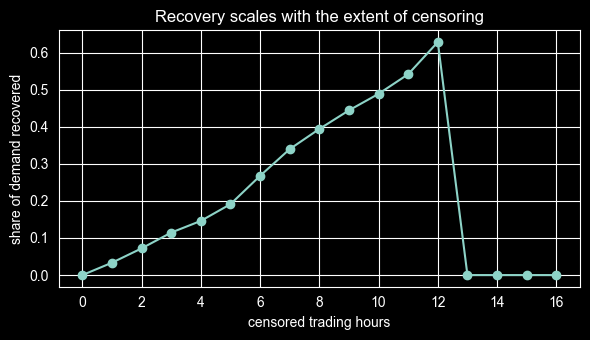

In [23]:
hourly = explode_hourly(subset)
daily = build_recovered_dataset()

print(f"censored trading hours: {hourly_censoring_rate(hourly):.3f}")
print(f"days with at least one censored hour: {daily_censoring_rate(hourly):.3f}")

uplift = (
    daily.assign(uplift=daily["imputed_demand"] / daily["latent_demand"].replace(0, np.nan))
    .groupby("censored_hours")["uplift"]
    .agg(["size", "mean"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(uplift.index, uplift["mean"], marker="o")
ax.set(xlabel="censored trading hours", ylabel="share of demand recovered",
       title="Recovery scales with the extent of censoring")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "censoring_uplift.png", dpi=150)
plt.show()

**+** The uplift curve is monotonic and smooth, rising from 3% at one censored hour to 63% at twelve. The mechanism behaves exactly as the reconstruction model predicts, which serves as independent confirmation of the method.

## 4. Censoring is orthogonal to the price

The correction moves the level of demand without changing its slope in price,
because stockouts are driven by replenishment policy rather than by demand
responding to promotions.

In [24]:
buckets = pd.cut(subset["discount"], [0.0, 0.7, 0.8, 0.9, 0.95, 0.99, 1.01])
print(subset.groupby(buckets, observed=True)
      .agg(n=("discount", "size"),
           censored_hours=("stock_hour6_22_cnt", "mean"),
           stockout_day=("stock_hour6_22_cnt", lambda s: (s > 0).mean()))
      .round(3))

print("\ncorrelation between multiplier and censored hours:",
      round(subset["discount"].corr(subset["stock_hour6_22_cnt"]), 3))

                  n  censored_hours  stockout_day
discount                                         
(0.0, 0.7]     2830           3.370         0.464
(0.7, 0.8]     3910           3.202         0.446
(0.8, 0.9]     6631           3.215         0.432
(0.9, 0.95]    3223           2.885         0.426
(0.95, 0.99]   1833           2.706         0.441
(0.99, 1.01]  20373           2.804         0.401

correlation between multiplier and censored hours: -0.045


## 5. Stock reconstructed from the stockout hour

On a day that sells out, cumulative sales up to the first stockout hour are
the stock that was there. That makes stock an observation on 38.8% of days
rather than an assumption, and replaces the earlier proxy of 1.2 times the
trailing seven-day mean.

                  estimated_stock        observed_demand       
                             size   mean            size   mean
stock_is_observed                                              
False                       23736  1.058           23736  0.889
True                        15064  1.073           15064  1.073


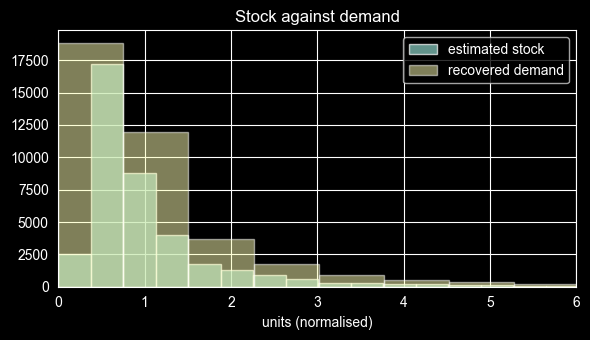

In [25]:
if "estimated_stock" in daily.columns:
    print(daily.groupby("stock_is_observed")[["estimated_stock", "observed_demand"]]
          .agg(["size", "mean"]).round(3))

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(daily["estimated_stock"], bins=60, alpha=0.7, label="estimated stock")
    ax.hist(daily["latent_demand"], bins=60, alpha=0.5, label="recovered demand")
    ax.set(xlim=(0, 6), xlabel="units (normalised)", title="Stock against demand")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "stock_vs_demand.png", dpi=150)
    plt.show()

## 6. The mediator

The first specification implied an elasticity of -0.40. At that value every
markdown reduces revenue, full price is optimal in every state, and dynamic
pricing has no case. The cause was the promotion indicators: `activity_flag`
correlates with the multiplier at -0.785, and `discount_depth` and
`is_promo` are functions of it. All three sit on the causal path from price
to demand, so conditioning on them blocks the effect the simulator exists to
represent. Removing the set raises the implied elasticity to -1.10 at no cost
in predictive accuracy.

Removing any single one changes almost nothing — the three are collinear and
each carries the same signal. That is the practical warning: excluding the
obvious campaign flag is not enough.

In [26]:
pd.read_csv(RESULTS_DIR / "mediator_ablation.csv").round(4)

,variant,n_features,r2,elasticity
0,without_mediators,27,0.6697,-1.0973
1,with_mediators,30,0.6575,-0.3824


#### Mediator comparison: elasticity shifts from −0.382 to −1.097; R² moves from 0.658 to 0.670. Dropping the mediator costs essentially nothing in fit but reverses the economic sign. Practically: removing any one of the three variables has no effect—they are collinear.

## 7. Feature attribution: gain against SHAP

Gain counts splits and favours high-cardinality continuous columns; SHAP
measures contribution to individual predictions. Computed on validation, so
attribution never sees the evaluation horizon.

In [27]:
ranking = pd.read_csv(RESULTS_DIR / "feature_ranking.csv", index_col=0)
ranking.head(15).round(4)

,shap,gain,rank_shap,rank_gain,rank_shift
product_id,0.2071,0.2020,1,3,2
observed_demand_roll14_mean,0.1734,0.2784,2,1,-1
observed_demand_roll7_mean,0.1402,0.2769,3,2,-1
discount,0.1245,0.0341,4,5,1
observed_demand_lag1,0.0535,0.0714,5,4,-1
weekday,0.0475,0.0126,6,8,2
store_id,0.0283,0.0049,7,20,13
discount_pair_mean,0.0267,0.0105,8,9,1
days_elapsed,0.0264,0.0049,9,19,10
holiday_flag,0.0227,0.0071,10,12,2


**+** SHAP ranking: discount_depth ranks fourth, discount sixth, and gain underestimates the price effect by a factor of three (0.059 vs. 0.162). Demand responds to the deviation from a product's typical price, not to the absolute price level.

## 8. The feature matrix handed to the models

In [37]:
from IPython.display import display

matrix = build_feature_matrix(daily)
features = get_feature_names(matrix)
train, valid, evaluation = temporal_split(matrix)

groups = {
    "action": ["discount"],
    "identity": [f for f in features if f.endswith("_id")],
    "calendar": [f for f in features if f in
                 ("weekday", "is_weekend", "day_of_month", "days_elapsed",
                  "weekday_sin", "weekday_cos", "holiday_flag")],
    "weather": [f for f in features if f in
                ("precpt", "log_precpt", "is_rainy", "avg_temperature",
                 "avg_humidity", "avg_wind_level")],
    "price history": [f for f in features if f.startswith("discount_")],
    "demand history": [f for f in features if f.startswith("observed_demand_")],
}

ungrouped = set(features) - {c for cols in groups.values() for c in cols}
if ungrouped:
    print("ungrouped:", ungrouped)

display(pd.DataFrame([
    {"group": name, "n": len(cols), "features": ", ".join(cols)}
    for name, cols in groups.items()
]).set_index("group"))

pd.Series({
    "features": len(features),
    "train rows": len(train),
    "validation rows": len(valid),
    "evaluation rows": len(evaluation),
    "action levels": len(ACTION_GRID),
}).to_frame("value")

,n,features
group,,
action,1,discount
identity,4,"store_id, product_id, first_category_id, secon..."
calendar,7,"holiday_flag, weekday, is_weekend, day_of_mont..."
weather,6,"precpt, avg_temperature, avg_humidity, avg_win..."
price history,2,"discount_lag1, discount_pair_mean"
demand history,7,"observed_demand_lag1, observed_demand_lag2, ob..."


,value
features,27
train rows,30400
validation rows,5600
evaluation rows,2800
action levels,8
